# Tree Methods Lecture 2 - Regression Trees, Boosting and Modelling on Bank Marketing Dataset

Agenda:
1. Regression trees - decision trees for regression problems.
2. Boosting - another algorithm for ensembling lots of decision trees
3. Tasks


In [2]:
import pandas as pd
import numpy as np
import urllib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

## Plot Functions

In [3]:
def plot_tree(model, features):
    plt.figure(figsize=(15, 10))
    tree.plot_tree(
        model,
        feature_names=features,
        proportion=True,
        precision=2,
        filled=True,
    )
    plt.show()


In [4]:
def plot_regression_fit(model, feature):
    X_train_hits = X_train[[feature]]
    feature_grid = np.linspace(X_train_hits[feature].min(), X_train_hits[feature].max(), 500)
    y_pred = model.predict(pd.DataFrame({feature: feature_grid}))

    target = y_train.name or "Salary"
    df_train_plot = X_train_hits.copy()
    df_train_plot[target] = y_train

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_train_plot, x=feature, y=target, alpha=0.7)

    if hasattr(model, "tree_"):
        plt.step(feature_grid, y_pred, where="post", color="crimson", linewidth=2)

        for threshold in model.tree_.threshold[model.tree_.feature >= 0]:
            plt.axvline(threshold, color="gray", linestyle="--", alpha=0.6)
    else:
        plt.plot(feature_grid, y_pred, color="darkgreen", linewidth=2)

    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{target} vs {feature}")
    plt.show()


## Regression Trees

The key difference between regression and classification trees is the loss function that the tree is trying to minimize. In classification trees we were splitting with the goal of reducing Gini impurity, right now we're doing the same but with residual sum of squares (RSS), which is a metric we have encountered before.

$$
\text{RSS} = \sum_{j=1}^{J} \sum_{i \in R_j} (y_i - \hat{y}_{R_j})^2
$$

where $R_j$ are the regions (leaves) of the tree and $\hat{y}_{R_j}$ is the mean of $y$ in region $R_j$. At each split, the tree finds the feature and threshold that minimize the total RSS across the two resulting child nodes.

### Data

We will use the **Hitters** dataset, which contains baseball player statistics together with their salaries.

Key variables:
- `Salary`: the player's salary. This will be our target variable.
- `Hits`: number of hits in the current season.
- `CHits`: cumulative career hits up to that point.
- `Runs`: number of runs scored in the current season.
- `CRuns`: cumulative career runs scored up to that point.


In [4]:
df_hit = pd.read_csv(
    "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Hitters.csv"
)
df_hit = df_hit[df_hit["Salary"].notnull()]
df_hit = df_hit[df_hit["CHits"].between(5, 3000)]
df_hit = df_hit[df_hit["Hits"].between(5, 3000)]


In [5]:
from sklearn.model_selection import train_test_split

X = df_hit.drop(columns=["Salary"])
y = df_hit["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Let's fit a regression tree and inspect it.

In [6]:
from sklearn.tree import DecisionTreeRegressor


In [10]:
feature = "CHits"
X_train_hits = X_train[[feature]]

model = DecisionTreeRegressor(max_depth=1)
model.fit(X_train_hits, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

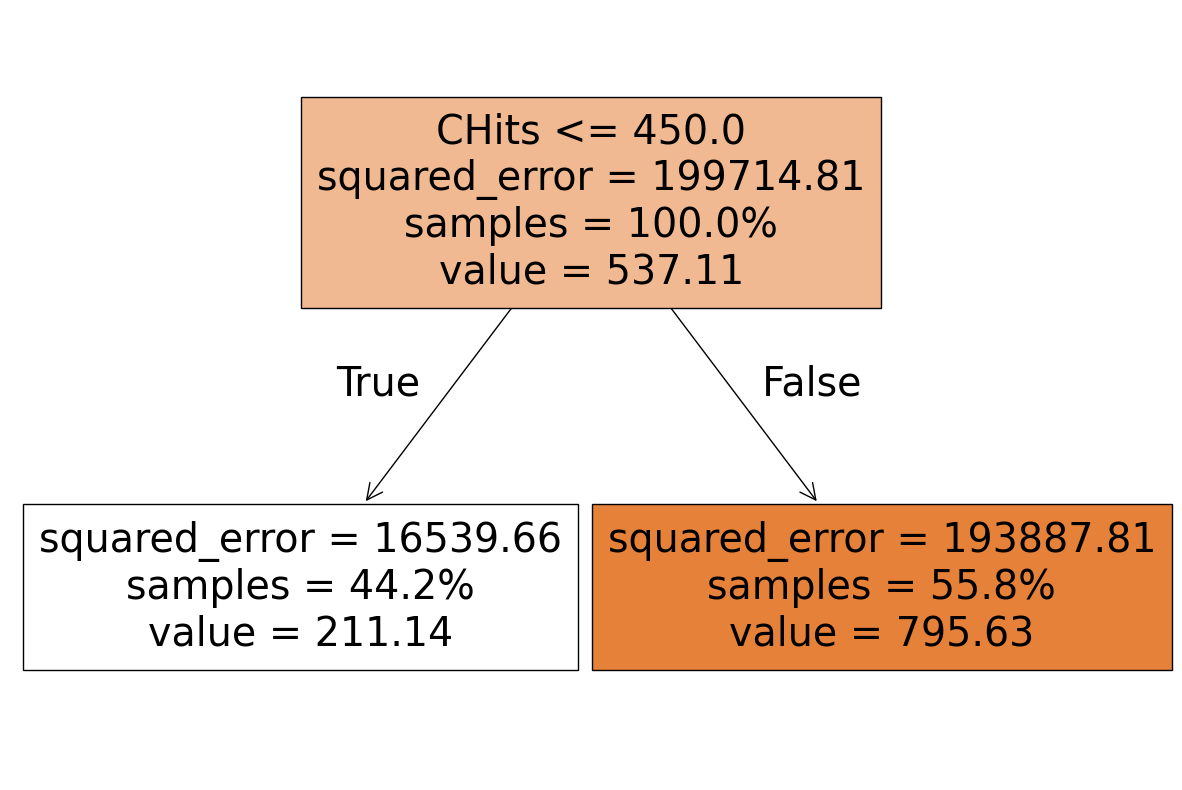

In [11]:
plot_tree(model, features=[feature])


We can also plot the function that the decision tree fits. Notice that it's a step function.

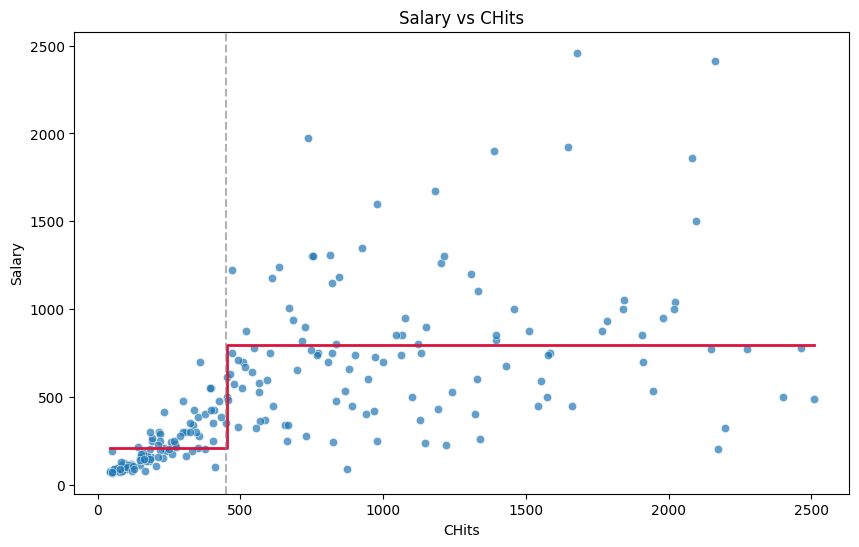

In [12]:
plot_regression_fit(model, feature)


We can increase `max_depth` above and see how as we increase the depth of the tree it keeps adding steps to the function, but the function remains jagged, because within each leaf we're predicting a constant - this is a limitation of decision trees that we discussed before.

## Task

Fit a random forest for predicting Salary as a function of CHits. Use n_estimators = 20 and max_depth = 2. Plot the function that the model fits to the data. What do you notice?


In [ ]:
from sklearn.ensemble import RandomForestRegressor


### Boosting

Bagging and random forests fit many trees independently and then average them. Boosting is different: it also aggregates many trees, but it fits them sequentially, with each new tree trying to correct what the trees fitted so far still get wrong.

For regression, the procedure is:
1. Start with a very simple model: predict the mean `Salary` for everyone.
2. Compute residuals: `Salary - current prediction`.
3. Fit a small regression tree to those residuals.
4. Add that tree's predictions to the current model, first multiplying it by the `learning_rate`.
5. Repeat steps 2-4 many times.

Learning rate controls how large an adjustment each new tree makes to the current model. If the learning rate is too high, the model can overfit more quickly because each tree has a large influence. If the learning rate is too low, the model usually needs more trees to learn the same pattern.

The final model is the sum of many small trees. Each individual tree is still a step function, so the boosted fit remains a step function, but it becomes more flexible with each added tree. This is called gradient boosting because, under squared-error loss, the residuals are exactly the negative gradient of the loss.


We will keep the same feature, `CHits`, and go through boosting one tree at a time.

**Step 1.** Start with the simplest possible model: predict the mean `Salary` for everyone. Then subtract that mean from `Salary`. Those are the initial residuals.


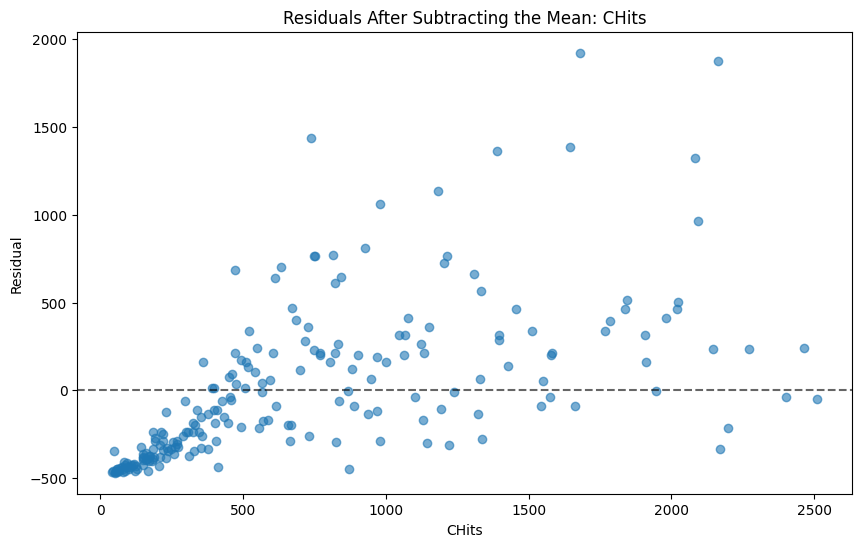

In [14]:
feature_grid = np.linspace(X_train_hits[feature].min(), X_train_hits[feature].max(), 500)
X_grid = pd.DataFrame({feature: feature_grid})
df_train_plot = X_train_hits.copy()
df_train_plot["Salary"] = y_train

learning_rate = 0.3
boosting_step = 0
mean_salary = y_train.mean()
current_fit_train = np.repeat(mean_salary, len(y_train))
current_fit_grid = np.repeat(mean_salary, len(feature_grid))
current_residuals = y_train - current_fit_train

plt.figure(figsize=(10, 6))
plt.scatter(X_train_hits[feature], current_residuals, alpha=0.6)
plt.axhline(0, color="black", linestyle="--", alpha=0.6)
plt.xlabel(feature)
plt.ylabel("Residual")
plt.title(f"Residuals After Subtracting the Mean: {feature}")
plt.show()


**Steps 2-4.** Run the next cell repeatedly. The left plot shows the new tree fitted to the current residuals. The right plot shows the updated overall fit on `Salary` after adding that tree.

We can run the cell below multiple times to see this in action.


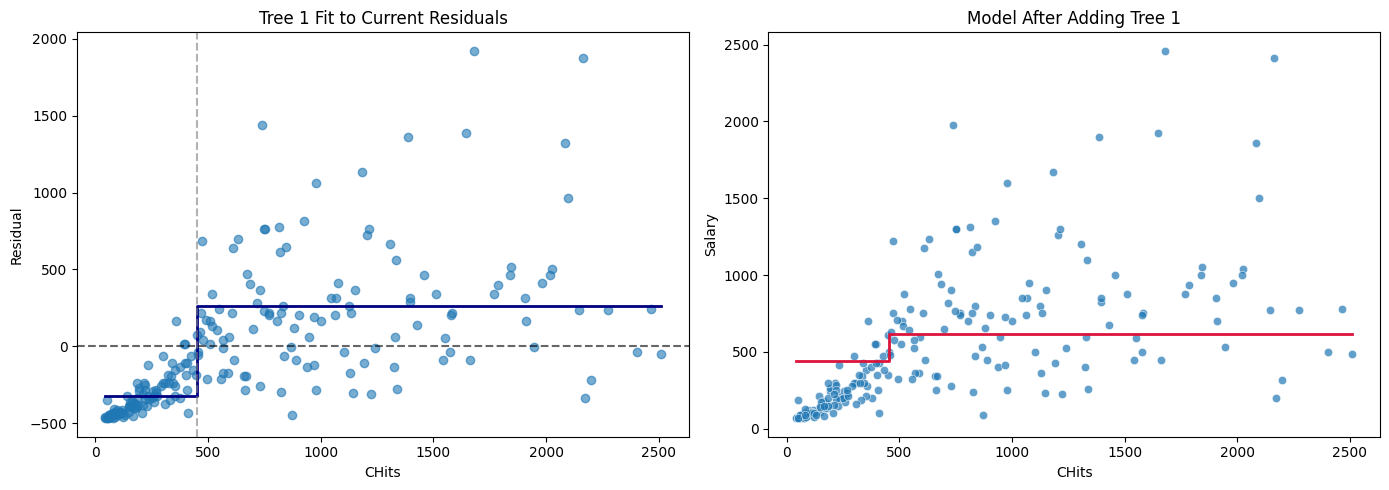

In [15]:
model = DecisionTreeRegressor(max_depth=1)
model.fit(X_train_hits, current_residuals)
tree_pred_train = model.predict(X_train_hits)
tree_pred_grid = model.predict(X_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train_hits[feature], current_residuals, alpha=0.6)
axes[0].step(feature_grid, tree_pred_grid, where="post", color="navy", linewidth=2)
for threshold in model.tree_.threshold[model.tree_.feature >= 0]:
    axes[0].axvline(threshold, color="gray", linestyle="--", alpha=0.6)
axes[0].axhline(0, color="black", linestyle="--", alpha=0.6)
axes[0].set_xlabel(feature)
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Tree {boosting_step + 1} Fit to Current Residuals")

current_fit_train = current_fit_train + learning_rate * tree_pred_train
current_fit_grid = current_fit_grid + learning_rate * tree_pred_grid
current_residuals = y_train - current_fit_train
boosting_step += 1

sns.scatterplot(data=df_train_plot, x=feature, y="Salary", alpha=0.7, ax=axes[1])
axes[1].step(feature_grid, current_fit_grid, where="post", color="crimson", linewidth=2)
axes[1].set_xlabel(feature)
axes[1].set_ylabel("Salary")
axes[1].set_title(f"Model After Adding Tree {boosting_step}")

plt.tight_layout()
plt.show()


This is what `GradientBoostingRegressor` automates: keep fitting small trees to the current residuals and keep adding those corrections to the overall model.

Gradient boosting remains one of the most widely used machine learning algorithms in practice, especially for tabular data. The most popular implementations are [XGBoost](https://xgboost.readthedocs.io/) and [LightGBM](https://lightgbm.readthedocs.io/).

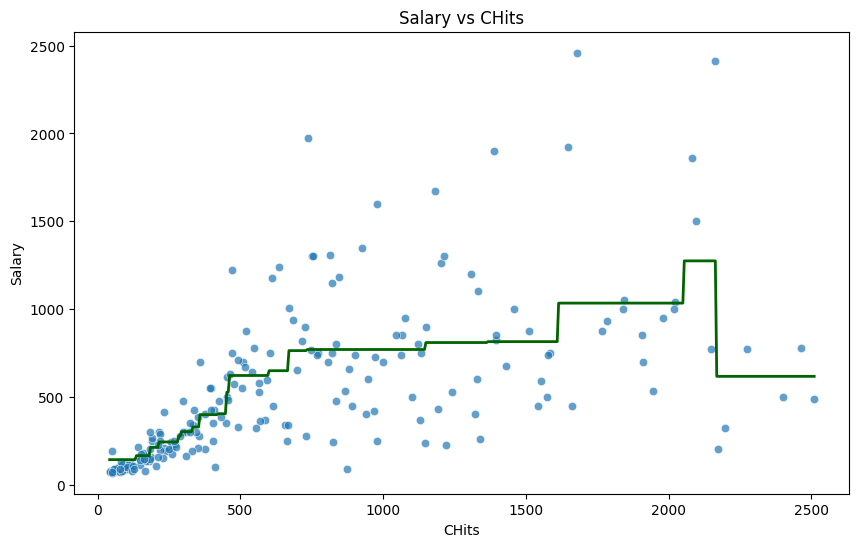

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=1, learning_rate=0.1)
gb_model.fit(X_train_hits, y_train)

plot_regression_fit(gb_model, feature)


## Big Task

Fit and compare random forest and gradient boosting tree algorithms. Perform hyperparameter tuning for both, with each tune at least two hyperparameters. Choose the best one and report its performance on the test set.

- You have to decide what preprocessing to perform.
- You have to decide which hyperparameters to tune, but keep in mind that the dataset is imbalanced.
- This is very close to what you have to do for the homework - fit several models and choose the best one.

Use the [**Bank Marketing**](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, which contains data from phone-based marketing campaigns of a Portuguese bank — the goal is to predict whether a client will subscribe to a term deposit (`y`).


In [5]:
url = 'https://pub-c88b3a7f2ed141418355b2bfb03c96e6.r2.dev/bank-marketing.csv'
request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request) as response:
    df = pd.read_csv(response, sep=';')


In [6]:
df = df[["balance", "housing", "loan", "job", "age", "campaign", "previous", "y"]]
df["y"] = df["y"].map({"yes": 1, "no": 0})


In [7]:
df.sample(5)

,balance,housing,loan,job,age,campaign,previous,y
3776,580,yes,no,blue-collar,40,1,0,0
9928,3644,no,no,services,47,2,0,0
33409,538,yes,no,student,25,1,0,0
31885,1773,no,no,management,42,1,1,0
15738,217,no,yes,management,56,2,0,0



Variables we will use:
- `balance`: average yearly balance in euros.
- `housing`: whether the client has a housing loan (`yes`/`no`).
- `loan`: whether the client has a personal loan (`yes`/`no`).
- `job`: type of job (e.g. `management`, `technician`, `blue-collar`, etc.).
- `age`: age of the client.
- `campaign`: number of contacts performed during this campaign.
- `previous`: number of contacts performed before this campaign.
- `y`: whether the client subscribed to a term deposit (`yes`/`no`) — this is our **target variable**.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   balance   45211 non-null  int64 
 1   housing   45211 non-null  object
 2   loan      45211 non-null  object
 3   job       45211 non-null  object
 4   age       45211 non-null  int64 
 5   campaign  45211 non-null  int64 
 6   previous  45211 non-null  int64 
 7   y         45211 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 2.8+ MB


In [9]:
df.value_counts("y")


y
0    39922
1     5289
Name: count, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

X = df.drop(columns=["y"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

categorical_features = ["job", "housing", "loan"]
numeric_features = ["balance", "age", "campaign", "previous"]


## Recap

- Regression trees work in a very similar fashion as classification trees, but the splitting criterion is based on mean squared error rather than Gini impurity.
- Bagging and random forests fit many trees independently and then average them, whereas boosting fits trees sequentially so each new tree tries to correct what the current ensemble still gets wrong.
- Key hyperparameters for gradient boosting:
    - `n_estimators` - the number of sequential trees to fit. More trees can improve performance but also increase the risk of overfitting and training time (different from bagging where increasing `n_estimators` does not result in overfitting).
    - `learning_rate` - controls how much each tree contributes to the overall model. Lower values require more trees but tend to generalize better.
    - `max_depth` - the depth of each individual tree. Boosting typically uses shallow trees (often depth 1-3), unlike random forests which use deeper trees.

Next week:
1. Midterm review
2. Feature importance
3. Feature selection
4. Model explainability